In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


Normalized SSD Results:

Small image: im01small.png      -> Original: im01.png     | Scale = 4.000 | SSD Nearest = 0.002096 | SSD Bilinear = 0.001770
Small image: im02small.png      -> Original: im02.png     | Scale = 4.000 | SSD Nearest = 0.000407 | SSD Bilinear = 0.000282
Small image: im03small.png      -> Original: im03.png     | Scale = 3.999 | SSD Nearest = 0.000951 | SSD Bilinear = 0.000771
Small image: taylor_small.jpg   -> Original: taylor.jpg   | Scale = 5.000 | SSD Nearest = 0.003661 | SSD Bilinear = 0.003429
Small image: taylor_very_small.jpg -> Original: taylor.jpg   | Scale = 20.000 | SSD Nearest = 0.007472 | SSD Bilinear = 0.006927


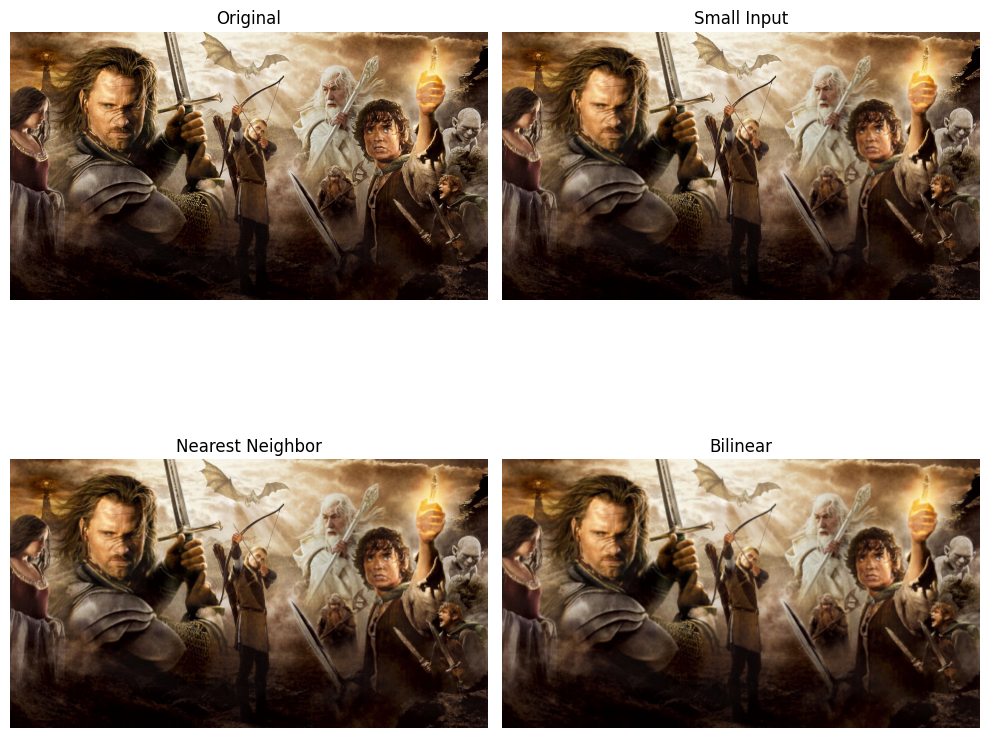

In [8]:

def zoom_image(image, s, method='nearest'):
    h, w = image.shape[:2]

    new_h = max(1, int(round(h * s)))
    new_w = max(1, int(round(w * s)))

    if method == 'nearest':
        interp = cv2.INTER_NEAREST
    elif method == 'bilinear':
        interp = cv2.INTER_LINEAR
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")

    return cv2.resize(image, (new_w, new_h), interpolation=interp)


# Normalized SSD
def normalized_ssd(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)

    return np.sum((original - reconstructed) ** 2) / (
        original.size * (255.0 ** 2)
    )

base_path = 'a1images/a1q8images'
save_path = 'results/ques7'

os.makedirs(save_path, exist_ok=True)

# Test image pairs
test_pairs = [
    ('im01.png', 'im01small.png'),
    ('im02.png', 'im02small.png'),
    ('im03.png', 'im03small.png'),
    ('taylor.jpg', 'taylor_small.jpg'),
    ('taylor.jpg', 'taylor_very_small.jpg')
]

results = []

# Process all test images
for original_name, small_name in test_pairs:

    original = cv2.imread(os.path.join(base_path, original_name))
    small = cv2.imread(os.path.join(base_path, small_name))

    if original is None:
        print("Failed to load:", original_name)
        continue

    if small is None:
        print("Failed to load:", small_name)
        continue

    h_big, w_big = original.shape[:2]
    h_small, w_small = small.shape[:2]

    sx = w_big / w_small
    sy = h_big / h_small
    s = (sx + sy) / 2.0

    # Zoom
    zoom_nn = zoom_image(small, s, method='nearest')
    zoom_bl = zoom_image(small, s, method='bilinear')

    # Resize exactly to original size
    zoom_nn = cv2.resize(zoom_nn, (w_big, h_big))
    zoom_bl = cv2.resize(zoom_bl, (w_big, h_big))

    # SSD
    ssd_nn = normalized_ssd(original, zoom_nn)
    ssd_bl = normalized_ssd(original, zoom_bl)

    results.append((small_name, original_name, s, ssd_nn, ssd_bl))

# Print Results
print("\nNormalized SSD Results:\n")

for row in results:
    print(
        f"Small image: {row[0]:18s} -> "
        f"Original: {row[1]:12s} | "
        f"Scale = {row[2]:.3f} | "
        f"SSD Nearest = {row[3]:.6f} | "
        f"SSD Bilinear = {row[4]:.6f}"
    )

# Example output visualization
example_original = cv2.imread(os.path.join(base_path, 'im01.png'))
example_small = cv2.imread(os.path.join(base_path, 'im01small.png'))

h_big, w_big = example_original.shape[:2]
h_small, w_small = example_small.shape[:2]

scale_example = h_big / h_small

example_nn = zoom_image(example_small, scale_example, 'nearest')
example_bl = zoom_image(example_small, scale_example, 'bilinear')

example_nn = cv2.resize(example_nn, (w_big, h_big))
example_bl = cv2.resize(example_bl, (w_big, h_big))

# Save outputs
cv2.imwrite(os.path.join(save_path, 'ques7_nearest.png'), example_nn)
cv2.imwrite(os.path.join(save_path, 'ques7_bilinear.png'), example_bl)

# Show images
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(example_original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Small Input")
plt.imshow(cv2.cvtColor(example_small, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Nearest Neighbor")
plt.imshow(cv2.cvtColor(example_nn, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Bilinear")
plt.imshow(cv2.cvtColor(example_bl, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'ques7_output.png'))
plt.show()